<a href="https://colab.research.google.com/github/ernestoaguaysol-unpaz/sistemas-inteligentes-2026/blob/main/02_redes_neuronales/001_suma_2_numeros_una_capa_varias_unidades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt

In [ ]:
X = np.array([
    [2, 2],
    [3, 8],
    [31, 6]
])
y = np.array([
    4,
    11,
    37
])

In [ ]:
# Creación de un modelo usando la API Sequential
# Una capa Densa seguida de otra
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(3, input_shape=(2,), activation="linear"),
])

2024-05-07 14:44:26.463073: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-05-07 14:44:26.463104: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: serena
2024-05-07 14:44:26.463109: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: serena
2024-05-07 14:44:26.463206: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 550.54.15
2024-05-07 14:44:26.463221: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 550.54.15
2024-05-07 14:44:26.463224: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:241] kernel version seems to match DSO: 550.54.15


In [ ]:
# Compilar el modelo: definir un optimizador, función de pérdida y métricas.
modelo.compile(
    # https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
    loss="mae",
    metrics=["mae"],
)

In [ ]:
modelo.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 3)                 9         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
modelo.get_weights()

[array([[ 1.0024676 , -0.2709753 ,  1.0060565 ],
        [ 0.02510726,  0.41084182, -0.4766664 ]], dtype=float32),
 array([0., 0., 0.], dtype=float32)]

In [ ]:
# Ver con distintos batch_size cómo avanza cada epoch
modelo.fit(X, y, batch_size=1, epochs=10)

Epoch 1/10
3/3 [==============================] - 0s 3ms/step - loss: 10.4529 - mae: 10.4529
Epoch 2/10
3/3 [==============================] - 0s 1ms/step - loss: 10.4355 - mae: 10.4355
Epoch 3/10
3/3 [==============================] - 0s 4ms/step - loss: 10.4182 - mae: 10.4182
Epoch 4/10
3/3 [==============================] - 0s 2ms/step - loss: 10.4008 - mae: 10.4008
Epoch 5/10
3/3 [==============================] - 0s 2ms/step - loss: 10.3835 - mae: 10.3835
Epoch 6/10
3/3 [==============================] - 0s 2ms/step - loss: 10.3661 - mae: 10.3661
Epoch 7/10
3/3 [==============================] - 0s 11ms/step - loss: 10.3488 - mae: 10.3488
Epoch 8/10
3/3 [==============================] - 0s 2ms/step - loss: 10.3314 - mae: 10.3314
Epoch 9/10
3/3 [==============================] - 0s 2ms/step - loss: 10.3141 - mae: 10.3141
Epoch 10/10
3/3 [==============================] - 0s 2ms/step - loss: 10.2968 - mae: 10.2968


In [ ]:
modelo_fit = modelo.fit(X, y, batch_size=1, epochs=5000, verbose=0)

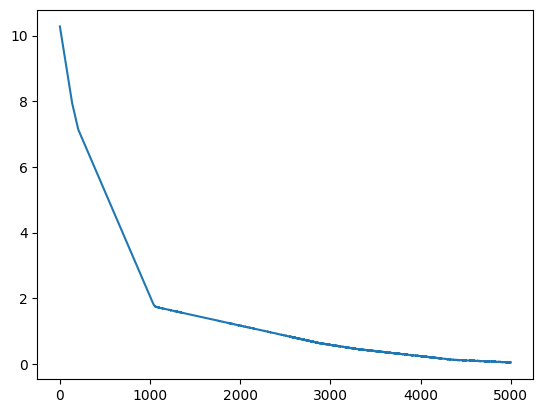

In [ ]:
plt.plot(modelo_fit.history['mae'])

In [ ]:
modelo.layers[0].get_weights()

[array([[0.99921834, 0.99976695, 0.9993522 ],
        [0.9836851 , 0.9987124 , 0.9624788 ]], dtype=float32),
 array([0.13563529, 0.01056665, 0.2674297 ], dtype=float32)]

In [ ]:
modelo.predict(X)

1/1 [==============================] - 0s 61ms/step


array([[ 4.1014423,  4.0075254,  4.191092 ],
       [11.002771 , 10.999567 , 10.965317 ],
       [37.013515 , 36.995617 , 37.02222  ]], dtype=float32)

In [ ]:
modelo.evaluate(X, y)

1/1 [==============================] - 0s 74ms/step - loss: 0.0420 - mae: 0.0420


[0.04200739040970802, 0.04200739040970802]